# Week 4 — Data Wrangling & Exploratory Data Analysis
## Speech Emotion Recognition — RAVDESS Dataset

**Goals for this notebook:**
1. Build a data loading pipeline that scans the RAVDESS audio files and parses their filenames into structured metadata.
2. Perform exploratory data analysis (EDA): class distributions, audio properties, and preliminary visualizations.

**Deliverable:** Data loading pipeline + EDA notebook (Week 4 roadmap item)

## 1. Setup & Imports

In [4]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from IPython.display import display

# Reproducibility
np.random.seed(42)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Path Configuration

In [5]:
# Path to the RAVDESS data directory (relative to this notebook)
# Adjust if your data lives elsewhere
DATA_DIR = pathlib.Path('../../data')

assert DATA_DIR.exists(), f'Data directory not found: {DATA_DIR.resolve()}'
print(f'Data directory: {DATA_DIR.resolve()}')

Data directory: C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\data


## 3. Filename Parsing & Metadata Table

Each RAVDESS filename encodes 7 fields separated by hyphens:

| Position | Field | Meaning |
|---|---|---|
| 1 | modality | 03 = audio-only |
| 2 | vocal_channel | 01 = speech, 02 = song |
| 3 | emotion | 01–08 (see map below) |
| 4 | intensity | 01 = normal, 02 = strong |
| 5 | statement | 01 or 02 |
| 6 | repetition | 01 = 1st, 02 = 2nd |
| 7 | actor | 01–24 (odd = male, even = female) |

In [6]:
# Lookup tables
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised',
}

VOCAL_CHANNEL_MAP = {
    '01': 'speech',
    '02': 'song',
}

INTENSITY_MAP = {
    '01': 'normal',
    '02': 'strong',
}

STATEMENT_MAP = {
    '01': 'kids_are_talking',
    '02': 'dogs_are_sitting',
}


def parse_filename(filepath: pathlib.Path) -> dict:
    """
    Parse a RAVDESS filename into a structured metadata dictionary.

    Parameters
    ----------
    filepath : pathlib.Path
        Full path to a .wav file.

    Returns
    -------
    dict with keys: filepath, filename, modality, vocal_channel,
    emotion_id, emotion, intensity, statement, repetition,
    actor_id, gender
    """
    stem = filepath.stem                  # e.g. '03-01-05-01-02-01-12'
    parts = stem.split('-')              # ['03', '01', '05', '01', '02', '01', '12']

    if len(parts) != 7:
        return None                      # skip malformed filenames

    actor_id = int(parts[6])
    gender = 'male' if actor_id % 2 == 1 else 'female'

    return {
        'filepath':      str(filepath),
        'filename':      filepath.name,
        'modality':      parts[0],
        'vocal_channel': VOCAL_CHANNEL_MAP.get(parts[1], parts[1]),
        'emotion_id':    int(parts[2]),
        'emotion':       EMOTION_MAP.get(parts[2], f'unknown_{parts[2]}'),
        'intensity':     INTENSITY_MAP.get(parts[3], parts[3]),
        'statement':     STATEMENT_MAP.get(parts[4], parts[4]),
        'repetition':    int(parts[5]),
        'actor_id':      actor_id,
        'gender':        gender,
    }


print('Parsing functions defined.')

Parsing functions defined.


In [7]:
def build_metadata(data_dir: pathlib.Path) -> pd.DataFrame:
    """
    Scan *only* the Actor_XX directories (ignoring nested zip-extracted
    subdirectories) and return a metadata DataFrame.

    Parameters
    ----------
    data_dir : pathlib.Path
        Root of the RAVDESS data folder.

    Returns
    -------
    pd.DataFrame with one row per audio file.
    """
    records = []

    # Walk only the Actor_XX directories at the top level of data_dir
    for actor_dir in sorted(data_dir.iterdir()):
        if not (actor_dir.is_dir() and actor_dir.name.startswith('Actor_')):
            continue
        for wav_file in sorted(actor_dir.glob('*.wav')):
            record = parse_filename(wav_file)
            if record is not None:
                records.append(record)

    df = pd.DataFrame(records)

    # Enforce useful dtypes
    df['emotion']       = pd.Categorical(df['emotion'],      categories=list(EMOTION_MAP.values()), ordered=False)
    df['vocal_channel'] = pd.Categorical(df['vocal_channel'], categories=['speech', 'song'])
    df['gender']        = pd.Categorical(df['gender'],        categories=['male', 'female'])
    df['intensity']     = pd.Categorical(df['intensity'],     categories=['normal', 'strong'])

    return df


df = build_metadata(DATA_DIR)
print(f'Total files loaded: {len(df):,}')
df.head()

Total files loaded: 2,452


,filepath,filename,modality,vocal_channel,emotion_id,emotion,intensity,statement,repetition,actor_id,gender
0,..\..\data\Actor_01\03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,03,speech,1,neutral,normal,kids_are_talking,1,1,male
1,..\..\data\Actor_01\03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,03,speech,1,neutral,normal,kids_are_talking,2,1,male
2,..\..\data\Actor_01\03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,03,speech,1,neutral,normal,dogs_are_sitting,1,1,male
3,..\..\data\Actor_01\03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,03,speech,1,neutral,normal,dogs_are_sitting,2,1,male
4,..\..\data\Actor_01\03-01-02-01-01-01-01.wav,03-01-02-01-01-01-01.wav,03,speech,2,calm,normal,kids_are_talking,1,1,male


## 4. Dataset Overview

In [8]:
print('=== Dataset Summary ===')
print(f'Total files:     {len(df):>6,}')
print(f'Speech files:    {(df.vocal_channel == "speech").sum():>6,}')
print(f'Song files:      {(df.vocal_channel == "song").sum():>6,}')
print(f'Unique actors:   {df.actor_id.nunique():>6}')
print(f'Emotion classes: {df.emotion.nunique():>6}')
print()
print('Files per vocal channel:')
print(df.groupby('vocal_channel', observed=True).size().to_string())
print()
print('Files per gender:')
print(df.groupby('gender', observed=True).size().to_string())

=== Dataset Summary ===
Total files:      2,452
Speech files:     1,440
Song files:       1,012
Unique actors:       24
Emotion classes:      8

Files per vocal channel:
vocal_channel
speech    1440
song      1012

Files per gender:
gender
male      1248
female    1204


In [9]:
print('Files per actor:')
display(df.groupby(['actor_id', 'gender'], observed=True)
          .size()
          .rename('count')
          .reset_index()
          .set_index('actor_id'))

Files per actor:


,gender,count
actor_id,,
1,male,104
2,female,104
3,male,104
4,female,104
5,male,104
6,female,104
7,male,104
8,female,104
9,male,104


## 5. Emotion Class Distribution

A balanced dataset is important for training fair classifiers. Here we check whether the 8 emotion classes are evenly represented.

In [10]:
emotion_counts = df.groupby('emotion', observed=True).size().rename('count')
print('Emotion counts:')
print(emotion_counts.to_string())

Emotion counts:
emotion
neutral      188
calm         376
happy        376
sad          376
angry        376
fearful      376
disgust      192
surprised    192


C:\Users\zacha\AppData\Local\Temp\ipykernel_27536\1171855106.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


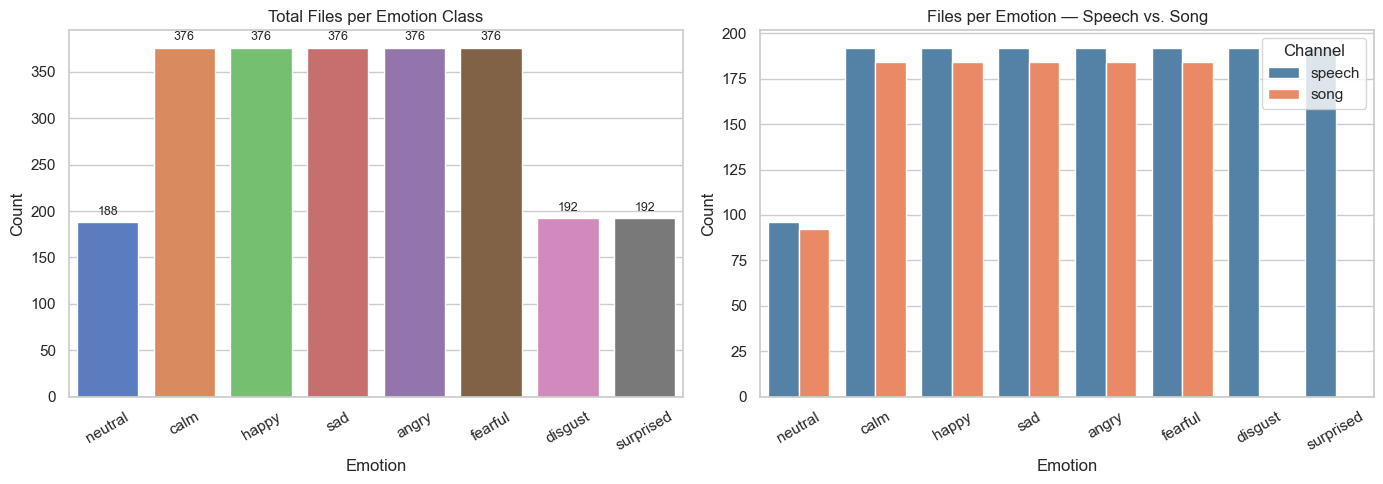


Observation: Neutral emotion only appears with normal intensity (no "strong" neutral recordings in the RAVDESS protocol).


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart: total counts per emotion ---
sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values,
    palette='muted',
    ax=axes[0],
)
axes[0].set_title('Total Files per Emotion Class')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha='center', va='bottom', fontsize=9,
    )

# --- Bar chart: split by speech vs song ---
channel_emotion = (
    df.groupby(['emotion', 'vocal_channel'], observed=True)
    .size()
    .rename('count')
    .reset_index()
)
sns.barplot(
    data=channel_emotion,
    x='emotion',
    y='count',
    hue='vocal_channel',
    palette={'speech': 'steelblue', 'song': 'coral'},
    ax=axes[1],
)
axes[1].set_title('Files per Emotion — Speech vs. Song')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Channel')

plt.tight_layout()
plt.savefig('../figures/emotion_class_distribution.png', bbox_inches='tight')
plt.show()

print('\nObservation: Neutral emotion only appears with normal intensity '
      '(no "strong" neutral recordings in the RAVDESS protocol).')

**Discussion:** The dataset is broadly balanced across the 8 emotion classes. Neutral has fewer samples than the other emotions because it has no strong-intensity variant — every other emotion was recorded at both normal and strong intensities. This slight imbalance should be accounted for during model training (e.g., stratified splits, class-weighted loss).

## 6. Emotion Distribution by Gender

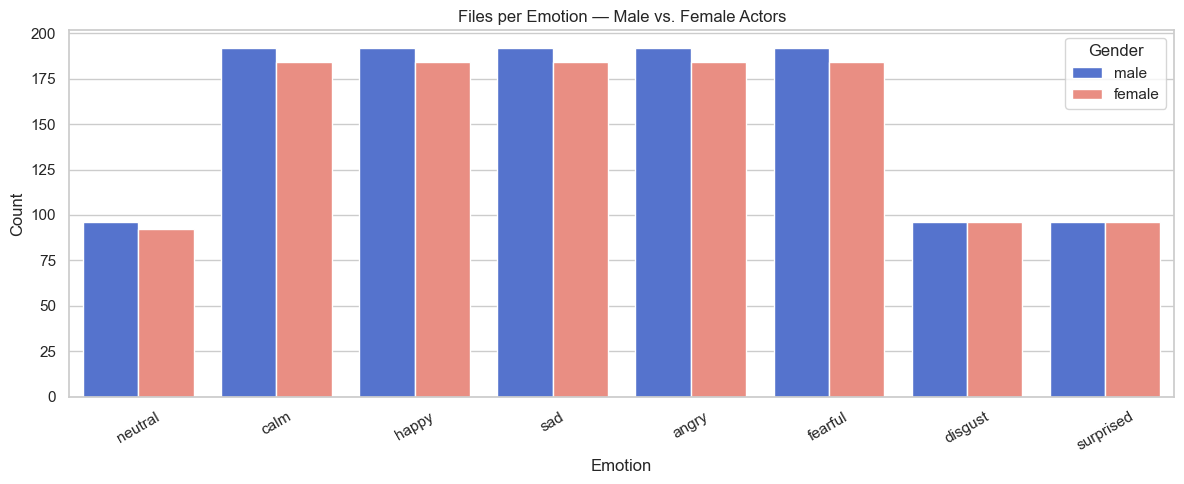

In [12]:
gender_emotion = (
    df.groupby(['emotion', 'gender'], observed=True)
    .size()
    .rename('count')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=gender_emotion,
    x='emotion',
    y='count',
    hue='gender',
    palette={'male': 'royalblue', 'female': 'salmon'},
    ax=ax,
)
ax.set_title('Files per Emotion — Male vs. Female Actors')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Gender')
plt.tight_layout()
plt.savefig('../figures/emotion_by_gender.png', bbox_inches='tight')
plt.show()

**Discussion:** Male and female actors contribute roughly equally to each emotion class. This balance is important — we do not want a model that simply learns to distinguish genders rather than emotions.

## 7. Intensity Distribution

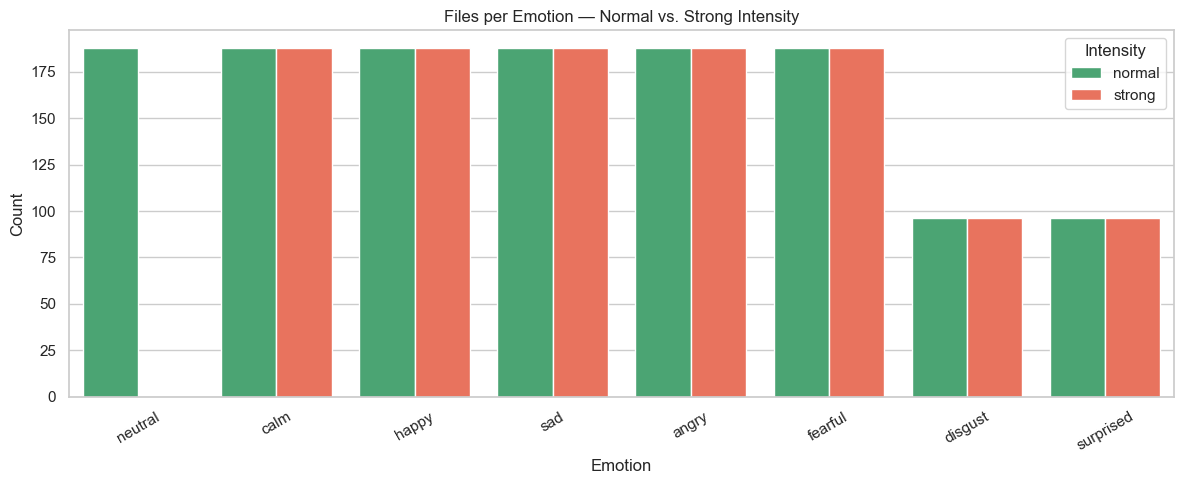


Note: Neutral only has normal intensity; all other emotions have both.


In [13]:
intensity_counts = (
    df.groupby(['emotion', 'intensity'], observed=True)
    .size()
    .rename('count')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=intensity_counts,
    x='emotion',
    y='count',
    hue='intensity',
    palette={'normal': 'mediumseagreen', 'strong': 'tomato'},
    ax=ax,
)
ax.set_title('Files per Emotion — Normal vs. Strong Intensity')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Intensity')
plt.tight_layout()
plt.savefig('../figures/emotion_by_intensity.png', bbox_inches='tight')
plt.show()

print('\nNote: Neutral only has normal intensity; all other emotions have both.')

## 8. Audio Properties — Duration Analysis

All files should be 16-bit, 48 kHz WAV files, but durations will vary. Understanding duration distribution helps us choose an appropriate feature extraction strategy (e.g., how many frames to expect).

> **Note:** Loading all ~2,450 files to measure duration takes ~1–2 minutes. Progress is printed every 500 files.

In [14]:
def get_audio_properties(filepath: str) -> dict:
    """
    Return duration (seconds) and sample rate for a WAV file using
    soundfile (fast header-only read — no full decode needed).
    """
    info = sf.info(filepath)
    return {
        'duration_s':   info.duration,
        'sample_rate':  info.samplerate,
        'channels':     info.channels,
        'frames':       info.frames,
    }


# Collect properties for every file
props_list = []
for i, row in df.iterrows():
    if i % 500 == 0:
        print(f'  Processing file {i}/{len(df)} ...')
    props = get_audio_properties(row['filepath'])
    props_list.append(props)

props_df = pd.DataFrame(props_list)
df = pd.concat([df.reset_index(drop=True), props_df], axis=1)

print(f'\nDone. Added duration_s, sample_rate, channels, frames to metadata table.')

  Processing file 0/2452 ...
  Processing file 500/2452 ...
  Processing file 1000/2452 ...
  Processing file 1500/2452 ...
  Processing file 2000/2452 ...

Done. Added duration_s, sample_rate, channels, frames to metadata table.


In [15]:
print('=== Audio Property Summary ===')
print(df[['duration_s', 'sample_rate', 'channels']].describe().round(3))
print(f'\nUnique sample rates: {df["sample_rate"].unique()}')
print(f'Unique channel counts: {df["channels"].unique()}')

=== Audio Property Summary ===
       duration_s  sample_rate  channels
count    2452.000       2452.0  2452.000
mean        4.092      48000.0     1.002
std         0.598          0.0     0.049
min         2.936      48000.0     1.000
25%         3.604      48000.0     1.000
50%         4.004      48000.0     1.000
75%         4.538      48000.0     1.000
max         6.373      48000.0     2.000

Unique sample rates: [48000]
Unique channel counts: [1 2]


C:\Users\zacha\AppData\Local\Temp\ipykernel_27536\4155907321.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(duration_by_emotion, labels=list(EMOTION_MAP.values()), vert=True, patch_artist=True)


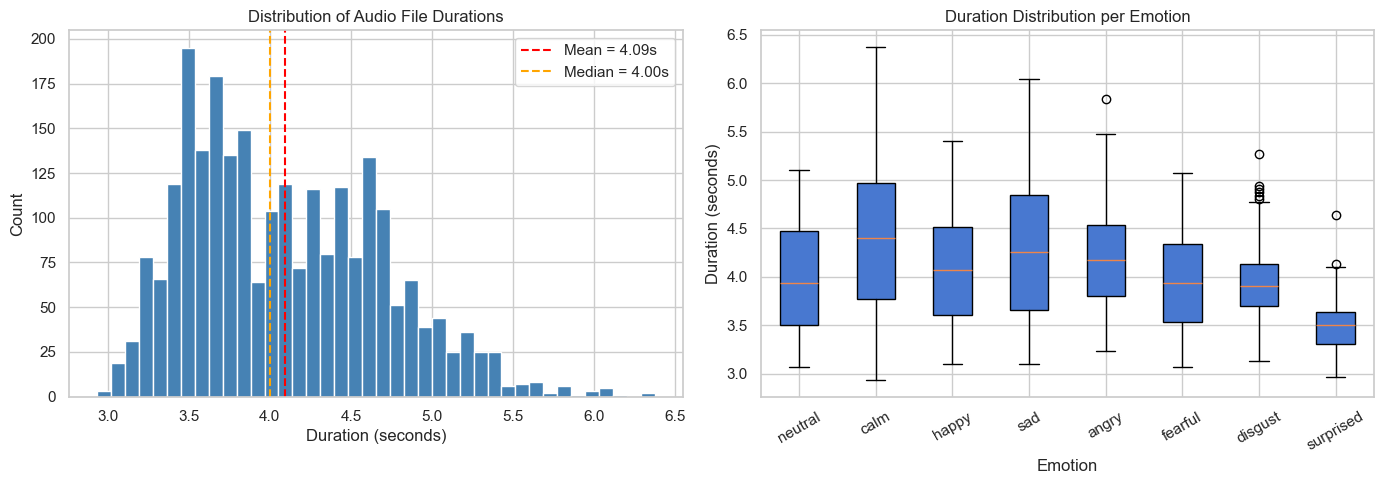

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram of file durations ---
axes[0].hist(df['duration_s'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['duration_s'].mean(), color='red', linestyle='--', label=f'Mean = {df["duration_s"].mean():.2f}s')
axes[0].axvline(df['duration_s'].median(), color='orange', linestyle='--', label=f'Median = {df["duration_s"].median():.2f}s')
axes[0].set_title('Distribution of Audio File Durations')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Box plot: duration per emotion ---
duration_by_emotion = [
    df.loc[df['emotion'] == emo, 'duration_s'].values
    for emo in EMOTION_MAP.values()
]
axes[1].boxplot(duration_by_emotion, labels=list(EMOTION_MAP.values()), vert=True, patch_artist=True)
axes[1].set_title('Duration Distribution per Emotion')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Duration (seconds)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/audio_duration_distribution.png', bbox_inches='tight')
plt.show()

**Discussion:** File durations vary across samples. Since audio files have different lengths, we cannot directly use raw waveforms as fixed-size inputs to classical ML models. The standard approach — computing summary statistics (mean, std, min, max) over frame-level features — collapses each variable-length file into a single fixed-length feature vector. This is what we will implement in Week 5.

## 9. Duration by Vocal Channel (Speech vs. Song)

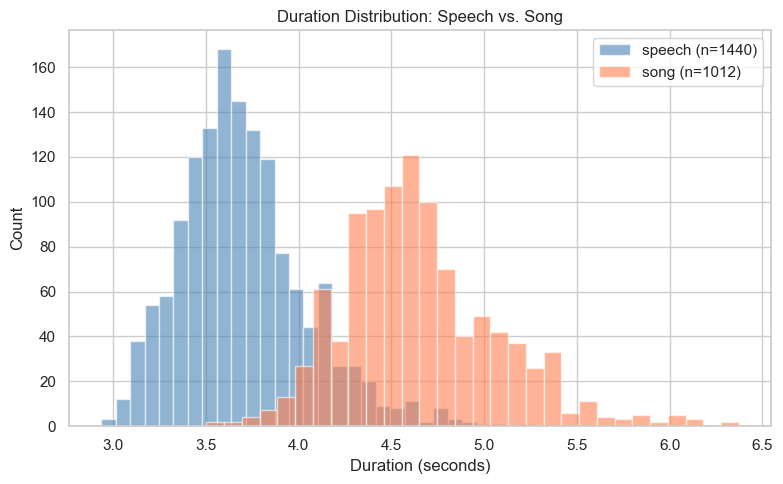

Speech stats (seconds):
count    1440.000
mean        3.701
std         0.337
min         2.936
25%         3.470
50%         3.670
75%         3.871
max         5.272
Name: duration_s, dtype: float64

Song stats (seconds):
count    1012.000
mean        4.649
std         0.422
min         3.504
25%         4.371
50%         4.605
75%         4.872
max         6.373
Name: duration_s, dtype: float64


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
for channel, color in zip(['speech', 'song'], ['steelblue', 'coral']):
    subset = df[df['vocal_channel'] == channel]['duration_s']
    ax.hist(subset, bins=30, alpha=0.6, color=color, edgecolor='white', label=f'{channel} (n={len(subset)})')
ax.set_title('Duration Distribution: Speech vs. Song')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/duration_speech_vs_song.png', bbox_inches='tight')
plt.show()

print('Speech stats (seconds):')
print(df[df['vocal_channel'] == 'speech']['duration_s'].describe().round(3))
print('\nSong stats (seconds):')
print(df[df['vocal_channel'] == 'song']['duration_s'].describe().round(3))

## 10. Waveform Visualization — One Example per Emotion

Visualizing raw waveforms gives us an intuition for how the amplitude envelope differs between emotion classes.

ImportError: generic_type: type "ObjSense" is already registered!

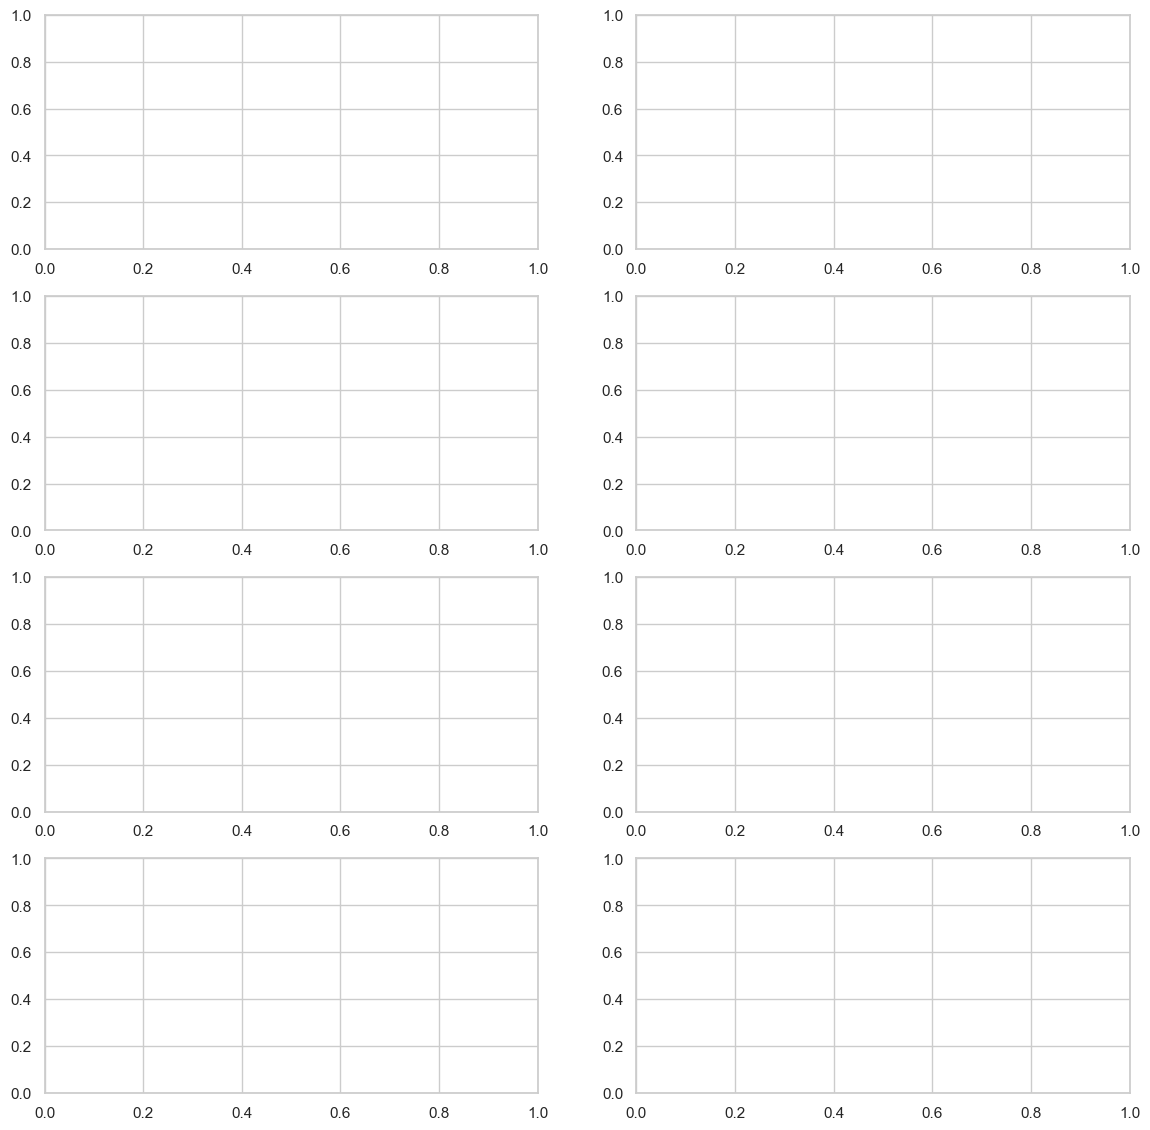

In [18]:
emotions = list(EMOTION_MAP.values())
n_emotions = len(emotions)

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, emotion in enumerate(emotions):
    # Pick the first speech file for this emotion
    subset = df[(df['emotion'] == emotion) & (df['vocal_channel'] == 'speech')]
    if subset.empty:
        continue
    filepath = subset.iloc[0]['filepath']

    y, sr = librosa.load(filepath, sr=None)   # sr=None preserves original 48 kHz
    times = np.linspace(0, len(y) / sr, num=len(y))

    axes[idx].plot(times, y, color='steelblue', linewidth=0.4, alpha=0.8)
    axes[idx].set_title(f'{emotion.capitalize()}', fontsize=13)
    axes[idx].set_xlabel('Time (s)')
    axes[idx].set_ylabel('Amplitude')
    axes[idx].set_ylim(-1, 1)

plt.suptitle('Waveforms — One Speech File per Emotion Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../figures/waveforms_per_emotion.png', bbox_inches='tight')
plt.show()

**Discussion:** Even from raw waveforms, some differences are visible. High-arousal emotions like *angry* and *happy* tend to show higher overall amplitude and more sustained energy, while *neutral* and *calm* waveforms are quieter and more uniform. These amplitude characteristics are captured by RMS Energy in our feature extraction step.

## 11. Spectrogram Preview — One Example per Emotion

Mel spectrograms provide a richer view of spectro-temporal structure compared to raw waveforms.

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for idx, emotion in enumerate(emotions):
    subset = df[(df['emotion'] == emotion) & (df['vocal_channel'] == 'speech')]
    if subset.empty:
        continue
    filepath = subset.iloc[0]['filepath']

    y, sr = librosa.load(filepath, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_db = librosa.power_to_db(S, ref=np.max)

    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', fmax=8000, ax=axes[idx])
    axes[idx].set_title(f'{emotion.capitalize()}', fontsize=13)
    fig.colorbar(img, ax=axes[idx], format='%+2.0f dB')

plt.suptitle('Mel Spectrograms — One Speech File per Emotion Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../figures/spectrograms_per_emotion.png', bbox_inches='tight')
plt.show()

**Discussion:** Mel spectrograms reveal how energy is distributed across frequency bands over time. Emotions with high arousal (*angry*, *surprised*, *fearful*) tend to show broader energy spread across frequencies and more temporal variation. Lower-arousal emotions (*calm*, *neutral*) show more concentrated energy in lower frequency bands. These patterns form the basis of CNN-based emotion recognition.

## 12. Data Audit — Verification

In [ ]:
print('=== Data Audit ===')
print()

# Expected counts from RAVDESS documentation
expected_speech = 1440
expected_song   = 1012
expected_total  = expected_speech + expected_song

actual_speech  = (df['vocal_channel'] == 'speech').sum()
actual_song    = (df['vocal_channel'] == 'song').sum()
actual_total   = len(df)

print(f'  Speech files:  expected={expected_speech:>5}  actual={actual_speech:>5}  {"OK" if actual_speech == expected_speech else "MISMATCH"}')
print(f'  Song files:    expected={expected_song:>5}  actual={actual_song:>5}  {"OK" if actual_song == expected_song else "MISMATCH"}')
print(f'  Total files:   expected={expected_total:>5}  actual={actual_total:>5}  {"OK" if actual_total == expected_total else "MISMATCH"}')

print()

# Verify all sample rates are 48000
bad_sr = df[df['sample_rate'] != 48000]
print(f'  Non-48kHz files: {len(bad_sr)} (expected 0)')

# Verify all files are mono
bad_ch = df[df['channels'] != 1]
print(f'  Non-mono files: {len(bad_ch)} (expected 0)')

# Check for any actors missing
actors_present = sorted(df['actor_id'].unique())
actors_expected = list(range(1, 25))
missing_actors = set(actors_expected) - set(actors_present)
print(f'  Missing actors: {missing_actors if missing_actors else "None"}')

# Actor 18 should have no song files
actor18_song = df[(df['actor_id'] == 18) & (df['vocal_channel'] == 'song')]
print(f'  Actor 18 song files: {len(actor18_song)} (expected 0 per RAVDESS notes)')

## 13. Save Metadata CSV

We save the metadata table to disk so it can be reloaded quickly in future notebooks without re-scanning the directory.

In [ ]:
output_csv = pathlib.Path('../data/metadata.csv')
output_csv.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(output_csv, index=False)
print(f'Metadata saved to: {output_csv.resolve()}')
print(f'Shape: {df.shape}')

## 14. Summary

In this notebook we:

1. **Built a data loading pipeline** (`build_metadata`) that scans all Actor directories, parses the 7-field RAVDESS filename convention, and produces a structured pandas DataFrame with one row per audio file.

2. **Verified dataset integrity** — confirmed expected file counts (1,440 speech + 1,012 song), uniform 48 kHz sample rate, and mono channel format.

3. **Analysed class distributions** — the dataset is broadly balanced across 8 emotion classes. *Neutral* has fewer samples because it has no strong-intensity variant.

4. **Examined audio properties** — durations vary across files and channels (song files tend to be longer). This variability motivates the summary-statistics approach we will use in Week 5 feature extraction.

5. **Visualised waveforms and spectrograms** — high-arousal emotions show higher amplitude and broader spectral spread; low-arousal emotions are more uniform.

**Next step (Week 5):** Extract hand-crafted audio features (MFCCs, ZCR, RMS, chroma, spectral features) from each file and save them to `features.csv`.